In [3]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

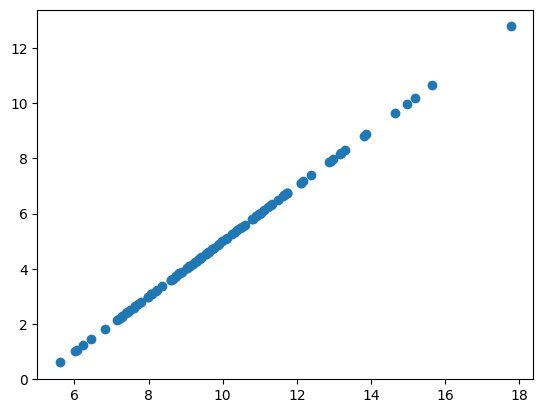

In [4]:
def GBM(S0, T, r, sigma, N):
    dt = T / N
    t = np.linspace(0, T, N)

    Wiener = np.cumsum(np.random.normal(0, np.sqrt(dt), size = N - 1))
    Wiener = np.concatenate(([0], Wiener))

    S = S0 * np.exp((r - 0.5 * sigma**2) * t + sigma * Wiener)
    return S

def BS_call(S, K, tau, r, sigma):
    #tau = T - t = time to maturity
    if tau <= 0:
        return max(S - K, 0)
    
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))
    d2 = d1 - sigma * np.sqrt(tau)

    call_price = S * stats.norm.cdf(d1) - K * np.exp(-r * tau) * stats.norm.cdf(d2)
    delta = stats.norm.cdf(d1)

    return call_price, delta

def delta_hedge(S, K, T, r, sigma, N_hedge):
    dt = T/N_hedge

    delta = np.zeros(N_hedge + 1)
    cash = np.zeros(N_hedge + 1)
    option = np.zeros(N_hedge + 1)

    #Initial hedge
    option[0], delta[0] = BS_call(S[0], K, T, r, sigma)

    #Sell option and buy delta shares
    cash[0] = option[0] - delta[0]*S[0]


    for i in range(N_hedge):
        tau = T - i*dt
        option[i], new_delta = BS_call(S[i], K, tau, r, sigma)

        #adjust stock position
        d_delta = new_delta - delta[i]
        
        #update cash account
        cash[i+1] = cash[i]*np.exp(r*dt) - d_delta*S[i]
        
        delta[i+1] = new_delta
    
    #Final portfolio
    option[-1] = max(S[-1]-K, 0)
    
    portfolio = cash[-1]*np.exp(r*dt) + delta[-1]*S[-1]
    
    hedge_error = portfolio - option[-1]

    return portfolio, hedge_error, S[-1]




T = 1
S0 = 10
mu = 0.05
sigma = 0.2
K = 5
N = 1000
r = 0.02
N_hedge = 100

portfolio_values = []
hedge_errors = []
final_S_values = []

for i in range(100):
    S = GBM(S0, T, r, sigma, N)
    P, E, final_S = delta_hedge(S, K, T, r, sigma, N_hedge)
    portfolio_values.append(P)
    hedge_errors.append(E)
    final_S_values.append(final_S)


plt.scatter(final_S_values, portfolio_values)